<h4>Import Libraries</h4>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

<h4>## Step 1: Create Dataset

We create a simple dataset where:
- Input (X): feature values
- Output (y): binary class (0 or 1)</h4>

In [2]:
X = np.array([1, 2, 3, 4, 5, 6])
y = np.array([0, 0, 0, 1, 1, 1])

X = X.reshape(-1, 1)
#Data is linearly separable
#First half belongs to class 0, second half to class 1

<h4>Train-Test split</h4>

In [3]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

<h4>Sigmoid Function</h4>

In [4]:
#Sigmoid converts values into probabilities between 0 and 1
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [5]:
#Output close to 0 → Class 0
#Output close to 1 → Class 1

<h4>## Step 4: Initialize Parameters</h4>

In [6]:
m = 0   # weight
b = 0   # bias
lr = 0.1
epochs = 1000

n = len(X_train)

In [7]:
#Learning rate controls speed of learning
#Epochs define number of iterations

<h4>## Step 5: Train Model using Gradient Descent</h4>

In [8]:
for i in range(epochs):
    z = m * X_train.flatten() + b
    y_pred = sigmoid(z)
    
    # gradients
    dm = (1/n) * np.sum((y_pred - y_train) * X_train.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    
    # update
    m = m - lr * dm
    b = b - lr * db

print("Weight:", m)
print("Bias:", b)

Weight: 1.6958039426194278
Bias: -5.870751063307466


In [9]:
#Model learns optimal weight and bias
#These parameters define decision boundary

<h4>## Step 6: Predictions</h4>

In [10]:
z_test = m * X_test.flatten() + b
y_prob = sigmoid(z_test)

y_pred_class = (y_prob >= 0.5).astype(int)

print("Actual:", y_test)
print("Predicted:", y_pred_class)
#Probabilities are converted into classes using threshold 0.5
#Model predictions can now be compared with actual values

Actual: [1 1]
Predicted: [1 1]


<h4>## Step 7: Evaluation Metrics</h4>

In [11]:
TP = np.sum((y_test == 1) & (y_pred_class == 1))
TN = np.sum((y_test == 0) & (y_pred_class == 0))
FP = np.sum((y_test == 0) & (y_pred_class == 1))
FN = np.sum((y_test == 1) & (y_pred_class == 0))

accuracy = (TP + TN) / len(y_test)
precision = TP / (TP + FP + 1e-8)
recall = TP / (TP + FN + 1e-8)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

#Accuracy shows overall correctness
#Precision shows correctness of positive predictions
#Recall shows ability to detect actual positives

Accuracy: 1.0
Precision: 0.999999995
Recall: 0.999999995


<h4>## Step 8: Visualization</h4>

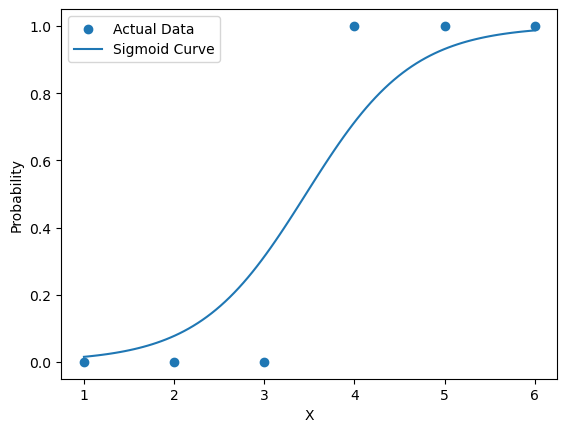

In [12]:
plt.scatter(X, y, label='Actual Data')

x_vals = np.linspace(min(X), max(X), 100)
y_vals = sigmoid(m * x_vals + b)

plt.plot(x_vals, y_vals, label='Sigmoid Curve')

plt.xlabel("X")
plt.ylabel("Probability")
plt.legend()
plt.show()